In [1]:
# ============================================
# CS223A Lecture 4 — DH Parameters & Forward Kinematics
# Day 4
# ============================================

import numpy as np

# DH Parameters: 4 numbers per joint
# a     = link length
# alpha = link twist
# d     = link offset
# theta = joint angle (variable for revolute joints)

print("Day 4 -- DH parameter & Forward Kinematics ")
print("="*45)

Day 4 -- DH parameter & Forward Kinematics 


In [4]:
# --- DH Transformation Matrix ---
# Each joint's 4x4 transform is built from 4 DH parameters
# T = Rz(theta) @ Tz(d) @ Tx(a) @ Rx(alpha)

def DH_transform(a , alpha, d, theta):
    ct = np.cos(theta)
    ca = np.cos(alpha)
    st = np.sin(theta)
    sa =np.sin(alpha)

    T = np.array([
        [ct, -st*ca , st*sa, a*ct],
        [st, ct*ca, -ct*ca, a*st], 
        [0, sa, ca, d],
        [0, 0, 0,1]
    ])
    return  T

# Test it with a simple joint
# Joint 1: no twist, no offset, link length=1, rotated 90 degrees

T1 = DH_transform(a=0 , alpha=0 ,d=0 , theta=np.radians(90))    

print("DH transform for joint 1 (theta = 90 degree)")
print(np.round(T1 ,3))
 

DH transform for joint 1 (theta = 90 degree)
[[ 0. -1.  0.  0.]
 [ 1.  0. -0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]


In [6]:
# --- 3-Joint Robot Arm Forward Kinematics ---
# A simple 3R planar robot (3 revolute joints)
# All joints rotate, all links in the same plane

# Link lengths (meters)

L1 = 1.0
L2 = 0.8
L3 = 0.5

#Joint angels (what we comtrol )
theta1 = np.radians(30)
theta2 = np.radians(45)
theta3 = np.radians(60)

# DH parameters for each joint
# Format: DH_transform(a, alpha, d, theta)
# For planar robot: alpha=0, d=0 for all joints

T1 = DH_transform(a=L1, alpha=0, d=0, theta=theta1)
T2 = DH_transform(a=L2, alpha=0, d=0, theta=theta2)
T3 = DH_transform(a=L3, alpha=0, d=0, theta=theta3)

# Chain them togather - Base to Endeffector
T_final = T1 @ T2 @ T3 

print("Transform T1 (Joint 1):")
print(np.round(T1, 3))
print("\nTransform T2 (Joint 2):")
print(np.round(T2, 3))
print("\nTransform T3 (Joint 3):")
print(np.round(T3, 3))
print("\nFinal End Effector Transform:")
print(np.round(T_final, 3))

# Extract  end effector position 
x = T_final[0 ,3]
y = T_final[1 ,3]
print(f"\n End Effector Position : x = {round(x,3)} ,y = {round(y ,3)}")

Transform T1 (Joint 1):
[[ 0.866 -0.5    0.     0.866]
 [ 0.5    0.866 -0.866  0.5  ]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

Transform T2 (Joint 2):
[[ 0.707 -0.707  0.     0.566]
 [ 0.707  0.707 -0.707  0.566]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

Transform T3 (Joint 3):
[[ 0.5   -0.866  0.     0.25 ]
 [ 0.866  0.5   -0.5    0.433]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

Final End Effector Transform:
[[-0.707 -0.707  0.837  0.72 ]
 [ 0.707 -0.707 -1.608  1.626]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

 End Effector Position : x = 0.72 ,y = 1.626


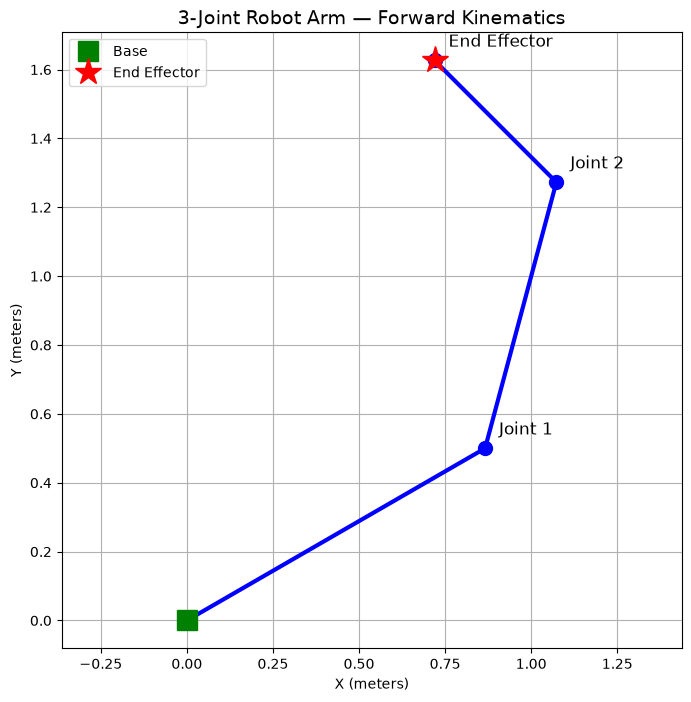

In [7]:
import matplotlib.pyplot as plt

# Calculate joint positions for plotting
origin = np.array([0,0,1])

p0 = np.array([0,0]) # Base 

T1_pos = T1 
p1 = np.array([T1_pos[0,3], T1_pos[1,3]])

T2_pos = T1 @ T2
p2 = np.array([T2_pos[0,3], T2_pos[1,3]])

T3_pos = T1 @ T2 @ T3
p3 = np.array([T3_pos[0,3], T3_pos[1,3]])

#plot 
plt.figure(figsize= (8,8))
points = np.array([p0 ,p1, p2, p3])

plt.plot(points[:,0], points[:,1], 'b-o', linewidth=3, markersize=10)
plt.plot(p0[0], p0[1], 'gs', markersize=15, label='Base')
plt.plot(p3[0], p3[1], 'r*', markersize=20, label='End Effector')

plt.annotate('Joint 1', p1, textcoords="offset points", xytext=(10,10), fontsize=12)
plt.annotate('Joint 2', p2, textcoords="offset points", xytext=(10,10), fontsize=12)
plt.annotate('End Effector', p3, textcoords="offset points", xytext=(10,10), fontsize=12)

plt.grid(True)
plt.axis('equal')
plt.title('3-Joint Robot Arm — Forward Kinematics', fontsize=14)
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.legend()
plt.show()